# **IRIS FLOWER CLASSIFICATION**

# **INTRODUCTION**

Predict the species of an Iris flower using Machine Learning based on flower measurements such as sepal length, sepal width, petal length, and petal width.

# **IMPORTING LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **LOAD DATA**

In [3]:
df = pd.read_csv("IRIS.csv")

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# **EXPLORATORY DATA ANALYSIS**

In [39]:
df.shape

(150, 5)

In [40]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# **STATISTICAL SUMMARY OF DATA**

In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


# **MISSING VALUE ANALYSIS**

In [41]:
df.isnull().sum()

,0
sepal_length,0
sepal_width,0
petal_length,0
petal_width,0
species,0


# **SPECIES DISTRIBUTION**

In [7]:
df["species"].value_counts()

,count
species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


# **SPECIES VISUALIZATION**

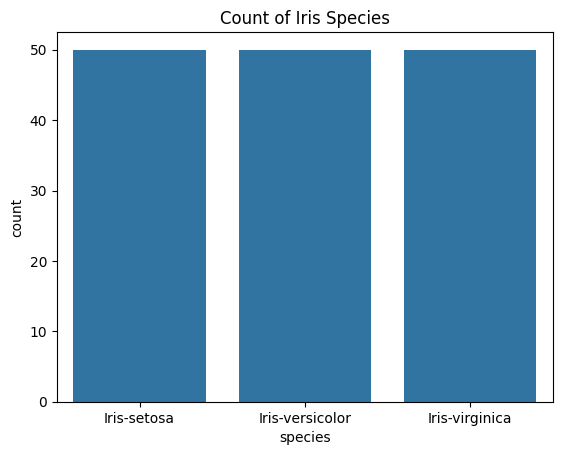

In [8]:
sns.countplot(x="species", data=df)

plt.title("Count of Iris Species")
plt.show()

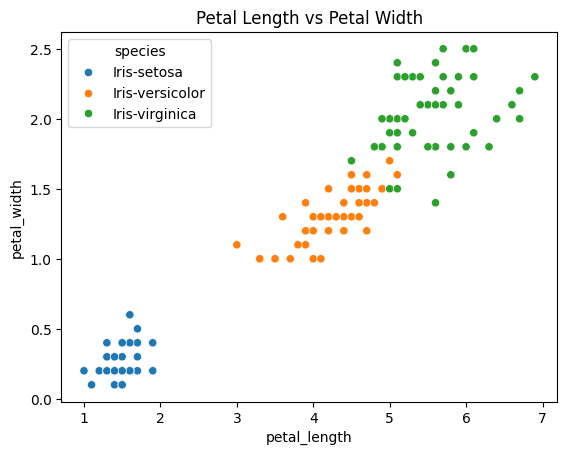

In [9]:
sns.scatterplot(
    x="petal_length",
    y="petal_width",
    hue="species",
    data=df
)

plt.title("Petal Length vs Petal Width")
plt.show()

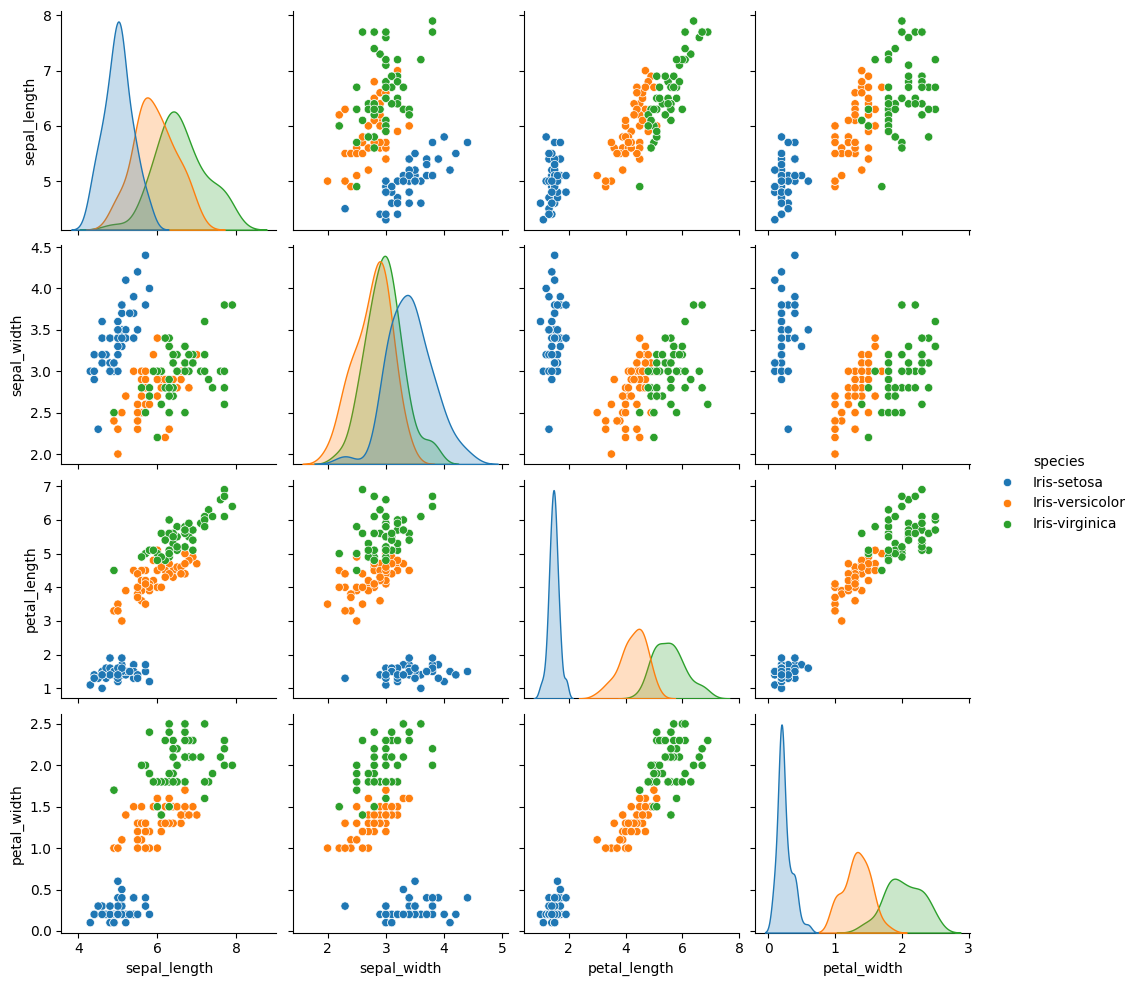

In [10]:
sns.pairplot(df, hue="species")

plt.show()

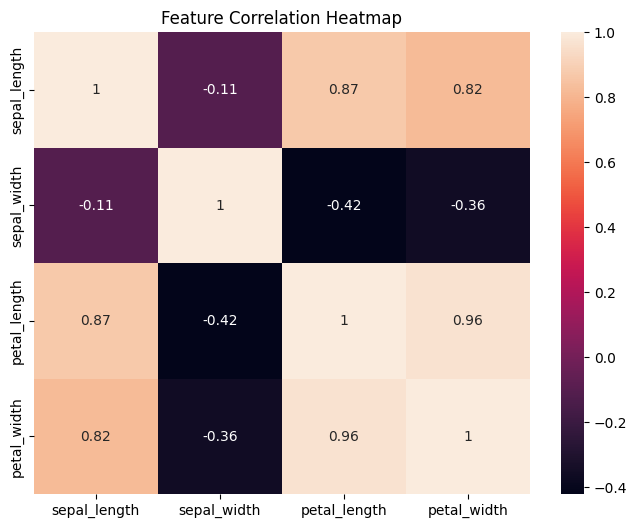

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.drop("species", axis=1).corr(), annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()

# **DATA PREPROCESSING**

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
encoder = LabelEncoder()

df["species"] = encoder.fit_transform(df["species"])

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# **FEATURE SEPERATION**

In [16]:
X = df.drop("species", axis=1)

y = df["species"]

# **TRAIN TEST SPLIT**

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# **LOGISTIC REGRESSION MODEL**

In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [21]:
y_pred = model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

In [23]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


# **CLASSIFICATION REPORT**

In [24]:
from sklearn.metrics import classification_report

In [25]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# **CONFUSION MATRIX**

In [26]:
from sklearn.metrics import confusion_matrix

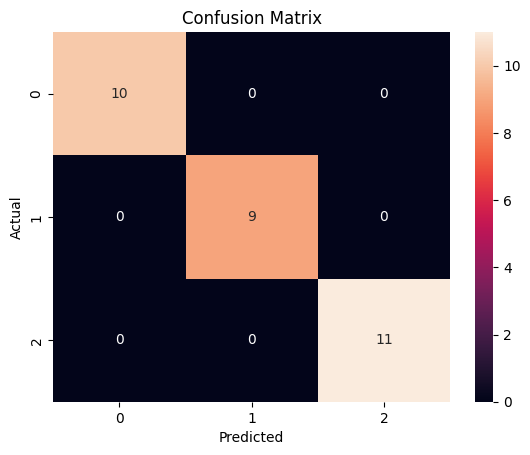

In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# **DECISION TREE MODEL**

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 1.0


# **RANDOM FOREST MODEL**

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


# **MODEL COMPARISION**

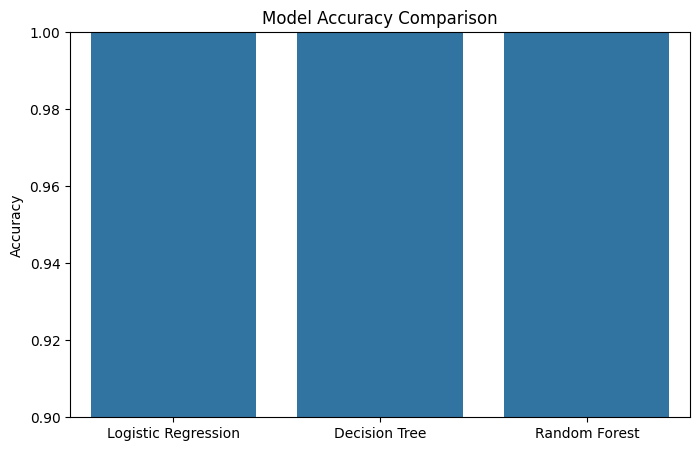

In [32]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]

scores = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(8,5))

sns.barplot(x=models, y=scores)

plt.ylim(0.9, 1.0)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

# **SAMPLE PREDICTION**

In [44]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

prediction = rf_model.predict(sample)

print("Predicted Class:", prediction[0])

Predicted Class: 0


In [45]:
species_name = encoder.inverse_transform(prediction)

print("Predicted Flower Species:", species_name[0])

Predicted Flower Species: Iris-setosa


# **MODEL SAVING**

In [36]:
import joblib

In [37]:
joblib.dump(rf_model, "iris_model.pkl")

['iris_model.pkl']

# **FEATURE IMPORTANCE**

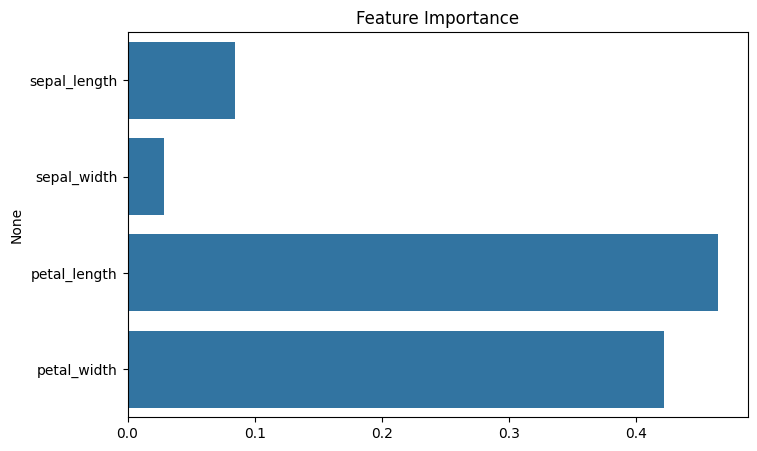

In [38]:
importance = rf_model.feature_importances_

features = X.columns

plt.figure(figsize=(8,5))

sns.barplot(x=importance, y=features)

plt.title("Feature Importance")

plt.show()

# **CONCLUSION**


The Iris Flower Classification project was successfully completed using multiple Machine Learning algorithms.

The dataset was analyzed, visualized, preprocessed, and used to train classification models capable of predicting flower species accurately.

Different Machine Learning models such as Logistic Regression, Decision Tree, and Random Forest were implemented and evaluated. All models achieved excellent prediction performance on the Iris dataset.

The Random Forest Classifier performed exceptionally well and was selected as the final model for prediction and model saving.

This project provided practical understanding of:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Data visualization
- Machine Learning classification
- Model evaluation
- Prediction systems
- Model saving techniques

The project demonstrates a complete beginner-friendly Machine Learning workflow and serves as a strong foundation for future AI and Data Science projects.

# **KEY INSIGHTS**


- The Iris dataset contains 150 flower samples and 3 flower species.
- The dataset was balanced with equal samples for each species.
- Petal measurements showed stronger influence in flower classification compared to sepal measurements.
- Data visualization helped identify clear separation between flower species.
- Machine Learning models achieved very high accuracy on the dataset.
- Random Forest Classifier provided excellent prediction performance.
- Feature importance analysis showed that petal length and petal width were the most important features for classification.
- The trained model was successfully saved using Joblib for future deployment and reuse.